# Task #35 (Story #6): Trực quan hóa xu hướng tỉ lệ trễ theo thời gian

Đọc `data/processed/orders_labeled.csv`, suy ra tháng mua hàng từ `order_purchase_timestamp`, tính tỉ lệ trễ theo Phương án A (loại nhóm NA, mẫu số = đơn xác định được — xem Task #34) theo 2 cách nhóm:
- Theo tháng thực tế (chuỗi thời gian năm-tháng) — thấy xu hướng tăng/giảm theo thời gian.
- Theo tháng trong năm, gộp các năm (mùa vụ) — thấy tính chu kỳ, nếu có.

Dữ liệu chỉ trải dài 2016-09 đến 2018-10 (~2 năm, 2 năm đầu/cuối không trọn năm), nên kết luận về mùa vụ cần thận trọng.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/orders_labeled.csv", low_memory=False)

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df["is_delayed"] = df["is_delayed"].astype("boolean")

# Phương án A: loại nhóm NA
df_determined = df[df["is_delayed"].notna()].copy()
df_determined["is_delayed"] = df_determined["is_delayed"].astype(bool)
df_determined["purchase_year_month"] = df_determined["order_purchase_timestamp"].dt.to_period("M")
df_determined["purchase_month"] = df_determined["order_purchase_timestamp"].dt.month

len(df_determined)

96476

## Tỉ lệ trễ theo tháng thực tế (chuỗi thời gian)

In [2]:
by_month = df_determined.groupby("purchase_year_month")["is_delayed"].agg(n_orders="count", n_delayed="sum")
by_month["pct_delayed"] = (by_month["n_delayed"] / by_month["n_orders"] * 100).round(2)
by_month

,n_orders,n_delayed,pct_delayed
purchase_year_month,,,
2016-09,1,1,100.00
2016-10,270,3,1.11
2016-12,1,0,0.00
2017-01,750,23,3.07
2017-02,1653,53,3.21
2017-03,2546,142,5.58
2017-04,2303,181,7.86
2017-05,3545,128,3.61
2017-06,3135,121,3.86


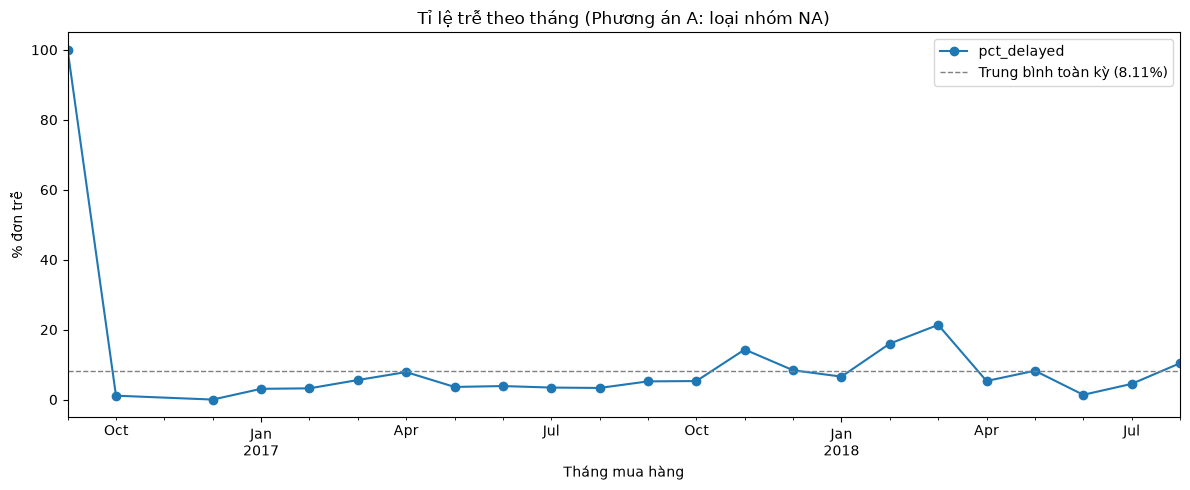

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
by_month["pct_delayed"].plot(ax=ax, marker="o")
ax.set_ylabel("% đơn trễ")
ax.set_xlabel("Tháng mua hàng")
ax.set_title("Tỉ lệ trễ theo tháng (Phương án A: loại nhóm NA)")
ax.axhline(8.11, color="gray", linestyle="--", linewidth=1, label="Trung bình toàn kỳ (8.11%)")
ax.legend()
plt.tight_layout()
plt.show()

## Tỉ lệ trễ theo tháng trong năm, gộp các năm (mùa vụ)

Lưu ý: dữ liệu chỉ có 2016 (chỉ 4 tháng cuối năm) và 2018 (chỉ đến tháng 10) trọn vẹn một phần — tháng 9-12 gộp dữ liệu từ cả 2016+2017, các tháng khác chủ yếu từ 2017-2018. Cỡ mẫu mỗi tháng được in kèm để đánh giá độ tin cậy.

In [4]:
by_month_of_year = df_determined.groupby("purchase_month")["is_delayed"].agg(n_orders="count", n_delayed="sum")
by_month_of_year["pct_delayed"] = (by_month_of_year["n_delayed"] / by_month_of_year["n_orders"] * 100).round(2)
by_month_of_year

,n_orders,n_delayed,pct_delayed
purchase_month,,,
1,7819,487,6.23
2,8209,1102,13.42
3,9549,1638,17.15
4,9101,542,5.96
5,10294,684,6.64
6,9231,204,2.21
7,10028,409,4.08
8,10544,799,7.58
9,4151,217,5.23


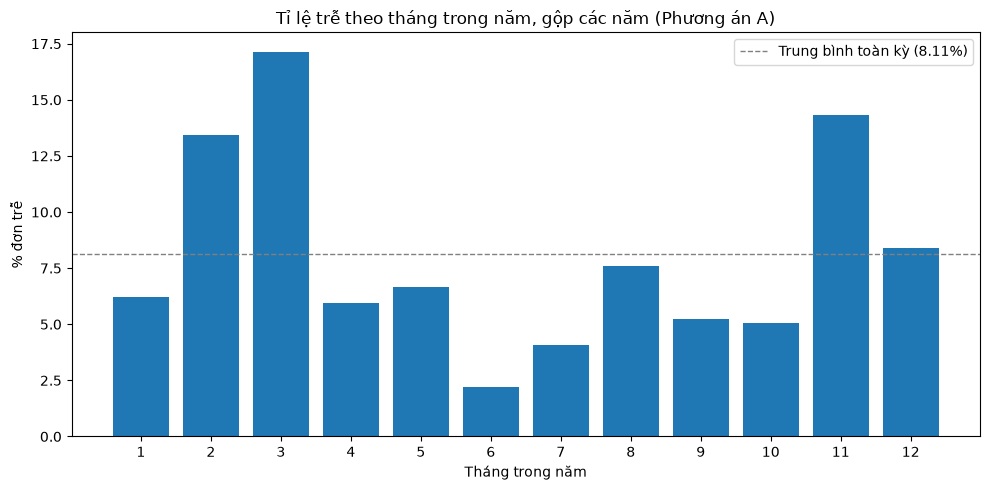

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_month_of_year.index, by_month_of_year["pct_delayed"])
ax.set_xticks(range(1, 13))
ax.set_ylabel("% đơn trễ")
ax.set_xlabel("Tháng trong năm")
ax.set_title("Tỉ lệ trễ theo tháng trong năm, gộp các năm (Phương án A)")
ax.axhline(8.11, color="gray", linestyle="--", linewidth=1, label="Trung bình toàn kỳ (8.11%)")
ax.legend()
plt.tight_layout()
plt.show()

## Kết luận

- **Theo tháng thực tế**: 3 tháng có tỉ lệ trễ tăng vọt rõ rệt so với trung bình toàn kỳ (8,11%): **2017-11 (14,31%, 7.288 đơn)**, **2018-02 (16,00%, 6.556 đơn)**, **2018-03 (21,36%, 7.003 đơn)**. Cỡ mẫu các tháng này đều đủ lớn (>6.500 đơn) nên không phải nhiễu do mẫu nhỏ — đây là tín hiệu vận hành thật, cần điều tra thêm nguyên nhân nghiệp vụ cụ thể (2017-11 trùng cao điểm mua sắm cuối năm/Black Friday, có thể do khối lượng đơn tăng vượt năng lực giao hàng).
- **Theo tháng trong năm (mùa vụ)**: tháng 2-3 nổi bật với tỉ lệ trễ cao (13,42% và 17,15%), nhưng phần lớn tín hiệu này đến từ riêng 2018 (do dữ liệu chỉ có 2 năm, năm 2016 gần như không có tháng 2-3). Vì vậy chưa đủ căn cứ kết luận đây là quy luật mùa vụ lặp lại hằng năm — cần thêm dữ liệu nhiều năm hơn để xác nhận.